# **CONFIGURATION**

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import numpy as np
import requests
from getpass import getpass
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')


# **DATASET1:** *aboard.csv*

In [ ]:
archive_path = "/content/drive/MyDrive/EduCost"
csv_path2 = os.path.join(archive_path, "International_Education_Costs.csv")
data_path2 = os.path.join(archive_path, "data")
df2 = pd.read_csv(csv_path2)

print("Vue globale du data International_Education_Costs.csv:")
print(f"\nStructure: {df2.shape}")
print(f"\nColonnes: {list(df2.columns)}\n")
print(df2.head(5))

Vue globale du data International_Education_Costs.csv:

Structure: (907, 12)

Colonnes: ['Country', 'City', 'University', 'Program', 'Level', 'Duration_Years', 'Tuition_USD', 'Living_Cost_Index', 'Rent_USD', 'Visa_Fee_USD', 'Insurance_USD', 'Exchange_Rate']

     Country       City                      University  \
0        USA  Cambridge              Harvard University   
1         UK     London         Imperial College London   
2     Canada    Toronto           University of Toronto   
3  Australia  Melbourne         University of Melbourne   
4    Germany     Munich  Technical University of Munich   

                  Program   Level  Duration_Years  Tuition_USD  \
0        Computer Science  Master             2.0        55400   
1            Data Science  Master             1.0        41200   
2      Business Analytics  Master             2.0        38500   
3             Engineering  Master             2.0        42000   
4  Mechanical Engineering  Master             2.0       

In [ ]:
df2.describe()

,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
count,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000
mean,2.836825,16705.016538,64.437486,969.206174,211.396913,700.077178,623.000695
std,0.945449,16582.385275,14.056333,517.154752,143.435740,320.374875,3801.746134
min,1.000000,0.000000,27.800000,150.000000,40.000000,200.000000,0.150000
25%,2.000000,2850.000000,56.300000,545.000000,100.000000,450.000000,0.920000
50%,3.000000,7500.000000,67.500000,900.000000,160.000000,650.000000,1.350000
75%,4.000000,31100.000000,72.200000,1300.000000,240.000000,800.000000,7.150000
max,5.000000,62000.000000,122.400000,2500.000000,490.000000,1500.000000,42150.000000


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 907 entries, 0 to 906
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            907 non-null    object 
 1   City               907 non-null    object 
 2   University         907 non-null    object 
 3   Program            907 non-null    object 
 4   Level              907 non-null    object 
 5   Duration_Years     907 non-null    float64
 6   Tuition_USD        907 non-null    int64  
 7   Living_Cost_Index  907 non-null    float64
 8   Rent_USD           907 non-null    int64  
 9   Visa_Fee_USD       907 non-null    int64  
 10  Insurance_USD      907 non-null    int64  
 11  Exchange_Rate      907 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 85.2+ KB


# **CLEANING**

In [ ]:
#verif s'il y a des vals manquantes et doublons
print(f"valeurs manquantes:\n{df2.isnull().sum()}")
print(f"Nombre de doublons : {df2.duplicated().sum()}")

valeurs manquantes:
Country              0
City                 0
University           0
Program              0
Level                0
Duration_Years       0
Tuition_USD          0
Living_Cost_Index    0
Rent_USD             0
Visa_Fee_USD         0
Insurance_USD        0
Exchange_Rate        0
dtype: int64
Nombre de doublons : 0


In [ ]:
#nettoyage des colonnes (enlever les espaces)
for col in ['Country','City','University','Program','Level']:
    df2[col] =df2[col].str.strip().str.title()

In [ ]:
#standardiser les colonnes
print("Pays uniques :", df2['Country'].nunique())
print("Niveaux uniques :", df2['Level'].unique())
print("Programmes uniques :", df2['Program'].nunique())

Pays uniques : 71
Niveaux uniques : ['Master' 'Bachelor' 'Phd']
Programmes uniques : 92


In [ ]:
df2[df2['Tuition_USD'] == 0].head() #pour traiter les program dont tuition=0

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
10,Sweden,Stockholm,Kth Royal Institute,Sustainable Technology,Master,2.0,0,71.8,1200,110,400,10.45
11,Denmark,Copenhagen,University Of Copenhagen,Bioinformatics,Master,2.0,0,73.4,1300,120,450,6.92
39,Sweden,Lund,Lund University,Neuroscience,Phd,4.0,0,69.5,1000,110,400,10.45
45,Denmark,Aalborg,Aalborg University,Computer Science,Bachelor,3.0,0,69.8,900,120,450,6.92
54,Germany,Berlin,Free University Of Berlin,International Business,Bachelor,3.0,0,65.2,900,75,550,0.92


In [ ]:
df2[df2['Tuition_USD'] != 0].head()

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
0,Usa,Cambridge,Harvard University,Computer Science,Master,2.0,55400,83.5,2200,160,1500,1.00
1,Uk,London,Imperial College London,Data Science,Master,1.0,41200,75.8,1800,485,800,0.79
2,Canada,Toronto,University Of Toronto,Business Analytics,Master,2.0,38500,72.5,1600,235,900,1.35
3,Australia,Melbourne,University Of Melbourne,Engineering,Master,2.0,42000,71.2,1400,450,650,1.52
4,Germany,Munich,Technical University Of Munich,Mechanical Engineering,Master,2.0,500,70.5,1100,75,550,0.92


     Country       City                      University  \
0        Usa  Cambridge              Harvard University   
1         Uk     London         Imperial College London   
2     Canada    Toronto           University Of Toronto   
3  Australia  Melbourne         University Of Melbourne   
4    Germany     Munich  Technical University Of Munich   

                  Program   Level  Duration_Years  Tuition_USD  \
0        Computer Science  Master             2.0        55400   
1            Data Science  Master             1.0        41200   
2      Business Analytics  Master             2.0        38500   
3             Engineering  Master             2.0        42000   
4  Mechanical Engineering  Master             2.0          500   

   Living_Cost_Index  Rent_USD  Visa_Fee_USD  Insurance_USD  Exchange_Rate  
0               83.5      2200           160           1500           1.00  
1               75.8      1800           485            800           0.79  
2               7

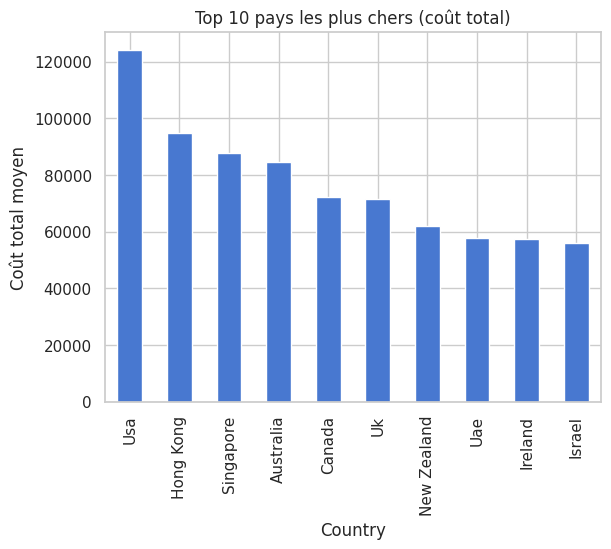

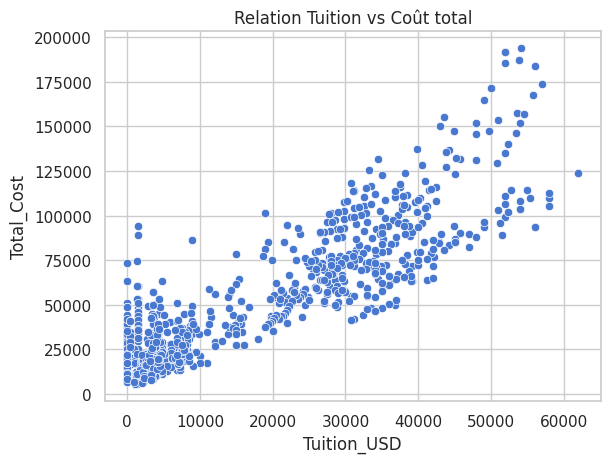

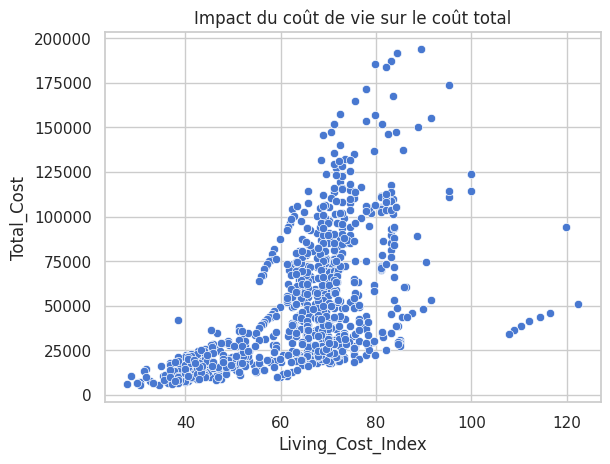

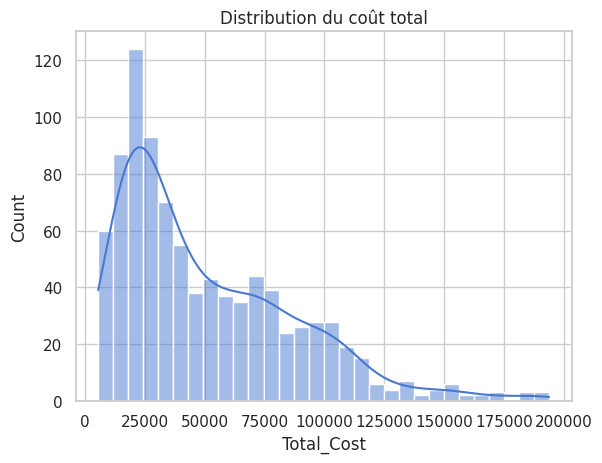

In [ ]:
  # ==============================
# OVERVIEW
# ==============================
print(df2.head())
print(df2.info())
print(df2.describe())

# ==============================
# CLEANING
# ==============================

# Renommer colonnes
df2.columns = df2.columns.str.strip()

# Conversion numérique
cols_numeric = [
    "Tuition_USD", "Rent_USD", "Visa_Fee_USD",
    "Insurance_USD", "Living_Cost_Index", "Duration_Years"
]

for col in cols_numeric:
    df2[col] = pd.to_numeric(df2[col], errors='coerce')

# Gestion NA
df2 = df2.dropna(subset=["Country", "Tuition_USD"])

# ==============================
# FEATURE ENGINEERING ⭐
# ==============================

df2["Total_Cost"] = (
    df2["Tuition_USD"] +
    (df2["Rent_USD"] * 12 * df2["Duration_Years"]) +
    df2["Visa_Fee_USD"] +
    df2["Insurance_USD"]
)

# ==============================
# ANALYSE
# ==============================

# Top pays les plus chers
top_total = df2.groupby("Country")["Total_Cost"].mean().sort_values(ascending=False)

plt.figure()
top_total.head(10).plot(kind="bar")
plt.title("Top 10 pays les plus chers (coût total)")
plt.ylabel("Coût total moyen")
plt.show()

# Relation Tuition vs Total Cost
plt.figure()
sns.scatterplot(data=df2, x="Tuition_USD", y="Total_Cost")
plt.title("Relation Tuition vs Coût total")
plt.show()

# Impact coût de vie
plt.figure()
sns.scatterplot(data=df2, x="Living_Cost_Index", y="Total_Cost")
plt.title("Impact du coût de vie sur le coût total")
plt.show()

# Distribution coût total
plt.figure()
sns.histplot(df2["Total_Cost"], bins=30, kde=True)
plt.title("Distribution du coût total")
plt.show()